# Model Trade-off

Compare model size, parameters, computation, inference time, and real-time factor (RTF).

Models:
- MosBeatNetV2
- MosquitoSong+
- SEDNet
- MTRCNN
- CF-ResNet-1D Small


In [2]:
import os
import sys
import time

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from torchinfo import summary

# works if notebook is in project root or notebooks/
root = os.getcwd()
if not os.path.isdir(os.path.join(root, "package")):
    root = os.path.abspath("..")

if root not in sys.path:
    sys.path.append(root)

from package.model import (
    MosbeatnetV2,
    MosqPlusModel,
    SEDNetSegmentLevel,
    CFResNet1DSmall,
)
from package.mrtcnn import MTRCNNSegmentLevel


In [19]:
# settings
n_classes = 9
n_segments = 20
segment_samples = 4000
audio_duration = 10.0

input_shape = (1, n_segments, 1, segment_samples)

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch: 2.5.1+cu121
CUDA: True
GPU: NVIDIA GeForce RTX 4090


In [20]:
models = {
    "MosBeatNetV2": MosbeatnetV2(
        n_timesteps=n_segments,
        n_outputs=n_classes
    ),
    "MosquitoSong+": MosqPlusModel(
        n_timesteps=segment_samples,
        n_outputs=n_classes
    ),
    "SEDNet": SEDNetSegmentLevel(
        sr=8000,
        segment_sec=0.5,
        n_classes=n_classes
    ),
    "MTRCNN": MTRCNNSegmentLevel(
        n_outputs=n_classes
    ),
    "CF-ResNet-1D Small": CFResNet1DSmall(
        num_classes=n_classes
    ),
}

list(models.keys())


['MosBeatNetV2', 'MosquitoSong+', 'SEDNet', 'MTRCNN', 'CF-ResNet-1D Small']

In [21]:
def count_params(model):
    return sum(p.numel() for p in model.parameters())


def model_size_mb(model):
    param_size = sum(p.numel() * p.element_size() for p in model.parameters())
    buffer_size = sum(b.numel() * b.element_size() for b in model.buffers())
    return (param_size + buffer_size) / (1024 ** 2)


def get_mult_adds(model):
    try:
        info = summary(
            model,
            input_size=input_shape,
            verbose=0,
            device="cpu"
        )
        return info.total_mult_adds
    except Exception as e:
        print("torchinfo failed:", type(model).__name__, "-", e)
        return np.nan


In [22]:
def measure_latency(model, device, warmup=5, runs=30):
    model = model.to(device).eval()
    x = torch.randn(*input_shape, device=device)

    with torch.no_grad():
        for _ in range(warmup):
            model(x)

    if device.type == "cuda":
        torch.cuda.synchronize()

    times = []

    with torch.no_grad():
        for _ in range(runs):
            if device.type == "cuda":
                torch.cuda.synchronize()

            start = time.perf_counter()
            model(x)

            if device.type == "cuda":
                torch.cuda.synchronize()

            times.append((time.perf_counter() - start) * 1000)

    return np.mean(times), np.std(times)


In [7]:
results = []

for name, model in models.items():
    print("Running:", name)

    params = count_params(model)
    size_mb = model_size_mb(model)
    mult_adds = get_mult_adds(model)

    cpu_mean, cpu_std = measure_latency(model, torch.device("cpu"))

    gpu_mean, gpu_std = np.nan, np.nan
    if torch.cuda.is_available():
        gpu_mean, gpu_std = measure_latency(model, torch.device("cuda"))

    results.append({
        "Model": name,
        "Params (M)": params / 1e6,
        "Size (MB)": size_mb,
        "Mult-Adds (G)": mult_adds / 1e9 if not np.isnan(mult_adds) else np.nan,
        "CPU Latency (ms)": cpu_mean,
        "CPU Std (ms)": cpu_std,
        "GPU Latency (ms)": gpu_mean,
        "GPU Std (ms)": gpu_std,
    })

df = pd.DataFrame(results)


Running: MosBeatNetV2
Running: MosquitoSong+
Running: SEDNet
Running: MTRCNN
Running: CF-ResNet-1D Small


In [24]:
df["CPU RTF"] = (df["CPU Latency (ms)"] / 1000) / audio_duration
df["GPU RTF"] = (df["GPU Latency (ms)"] / 1000) / audio_duration

display(
    df.round({
        "Params (M)": 3,
        "Size (MB)": 2,
        "Mult-Adds (G)": 3,
        "CPU Latency (ms)": 2,
        "CPU Std (ms)": 2,
        "GPU Latency (ms)": 2,
        "GPU Std (ms)": 2,
        "CPU RTF": 4,
        "GPU RTF": 4,
    })
)


,Model,Params (M),Size (MB),Mult-Adds (G),CPU Latency (ms),CPU Std (ms),GPU Latency (ms),GPU Std (ms),CPU RTF,GPU RTF,Macro-F1,Env F1 Mean,Env F1 Std,Env F1 Min,Env F1 Max
0,MosBeatNetV2,0.513,1.96,1.016,7.01,0.17,0.48,0.01,0.0007,0.0000,0.8511,0.778771,0.094381,0.6786,0.8888
1,MosquitoSong+,0.529,2.02,0.517,1.34,0.01,0.18,0.00,0.0001,0.0000,0.8042,0.741929,0.109547,0.6354,0.8881
2,SEDNet,1.063,4.14,0.138,2.56,0.45,0.31,0.02,0.0003,0.0000,0.7997,0.721714,0.065610,0.6489,0.8168
3,MTRCNN,0.240,0.95,1.952,16.22,4.86,0.66,0.03,0.0016,0.0001,0.8205,0.742286,0.076471,0.6528,0.8356
4,CF-ResNet-1D Small,2.646,10.10,9.517,34.46,1.63,1.06,0.01,0.0034,0.0001,0.8000,0.716686,0.114861,0.5735,0.8443


## Performance results

Use the pooled `all_domains` result as the main Macro-F1 for the trade-off table.

Also calculate mean, standard deviation, minimum, and maximum Macro-F1 across individual mosquito+background test environments.


In [25]:
result_file = "/home/mosbnet/mosdet/mosbeatnet_main/output/xdomain_exp6_all_sources_sp5/all_environment_evaluation_summary.tsv"

res = pd.read_csv(result_file, sep="\t")

name_map = {
    "mosbeatnet_v2": "MosBeatNetV2",
    "mosqplus": "MosquitoSong+",
    "sednet": "SEDNet",
    "mtrcnn": "MTRCNN",
    "cfresnet1d_small": "CF-ResNet-1D Small",
}

res["Model Name"] = res["Model"].map(name_map)

display(
    res[["Model", "Eval Set", "Test Type", "Label", "Seg Macro F1"]].head(10)
)


,Model,Eval Set,Test Type,Label,Seg Macro F1
0,cfresnet1d_small,all_domains,Pooled,Species,0.8000
1,cfresnet1d_small,biodcase_forest,Mosquito+Background,Species,0.6896
2,cfresnet1d_small,biodcase_urban,Mosquito+Background,Species,0.6569
3,cfresnet1d_small,humbug_forest,Mosquito+Background,Species,0.8443
4,cfresnet1d_small,humbug_urban,Mosquito+Background,Species,0.8188
5,cfresnet1d_small,indoor_forest,Mosquito+Background,Species,0.5993
6,cfresnet1d_small,indoor_urban,Mosquito+Background,Species,0.5735
7,cfresnet1d_small,noise_only,Noise-only,Species,NaN
8,cfresnet1d_small,outdoor_gaussian,Mosquito+Background,Species,0.8344
9,mosbeatnet_v2,all_domains,Pooled,Species,0.8511


In [26]:
# main performance: pooled result over all domains
pooled = res[
    (res["Eval Set"] == "all_domains") &
    (res["Test Type"] == "Pooled")
].copy()

f1_df = (
    pooled[["Model Name", "Seg Macro F1"]]
    .rename(columns={
        "Model Name": "Model",
        "Seg Macro F1": "Macro-F1"
    })
)

display(f1_df.round(4))


,Model,Macro-F1
0,CF-ResNet-1D Small,0.8000
9,MosBeatNetV2,0.8511
18,MosquitoSong+,0.8042
27,MTRCNN,0.8205
36,SEDNet,0.7997


In [27]:
# robustness across individual mosquito+background environments
env_res = res[
    (res["Test Type"] == "Mosquito+Background") &
    (~res["Eval Set"].isin(["all_domains", "noise_only"]))
].copy()

robustness = (
    env_res.groupby("Model Name")["Seg Macro F1"]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
    .rename(columns={
        "Model Name": "Model",
        "mean": "Env F1 Mean",
        "std": "Env F1 Std",
        "min": "Env F1 Min",
        "max": "Env F1 Max",
    })
)

display(robustness.round(4))


,Model,Env F1 Mean,Env F1 Std,Env F1 Min,Env F1 Max
0,CF-ResNet-1D Small,0.7167,0.1149,0.5735,0.8443
1,MTRCNN,0.7423,0.0765,0.6528,0.8356
2,MosBeatNetV2,0.7788,0.0944,0.6786,0.8888
3,MosquitoSong+,0.7419,0.1095,0.6354,0.8881
4,SEDNet,0.7217,0.0656,0.6489,0.8168


In [29]:
# combine complexity + performance
df = df.drop(
    columns=["Macro-F1", "Env F1 Mean", "Env F1 Std", "Env F1 Min", "Env F1 Max"],
    errors="ignore"
)

df = df.merge(f1_df, on="Model", how="left")
df = df.merge(robustness, on="Model", how="left")

final_cols = [
    "Model",
    "Params (M)",
    "Size (MB)",
    "Mult-Adds (G)",
    "CPU Latency (ms)",
    "CPU RTF",
    "GPU Latency (ms)",
    "GPU RTF",
    "Macro-F1",
    "Env F1 Mean",
    "Env F1 Std",
]

display(df[final_cols].round(4))


,Model,Params (M),Size (MB),Mult-Adds (G),CPU Latency (ms),CPU RTF,GPU Latency (ms),GPU RTF,Macro-F1,Env F1 Mean,Env F1 Std
0,MosBeatNetV2,0.5127,1.9604,1.0158,7.0122,0.0007,0.4751,0.0000,0.8511,0.7788,0.0944
1,MosquitoSong+,0.5286,2.0166,0.5168,1.3377,0.0001,0.1811,0.0000,0.8042,0.7419,0.1095
2,SEDNet,1.0634,4.1396,0.1379,2.5570,0.0003,0.3115,0.0000,0.7997,0.7217,0.0656
3,MTRCNN,0.2400,0.9510,1.9525,16.2240,0.0016,0.6635,0.0001,0.8205,0.7423,0.0765
4,CF-ResNet-1D Small,2.6461,10.0993,9.5172,34.4629,0.0034,1.0637,0.0001,0.8000,0.7167,0.1149


## Trade-off plots

The main plots use pooled `Macro-F1` from `all_domains`.


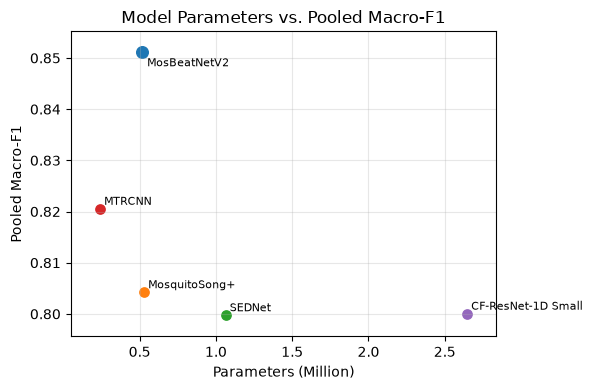

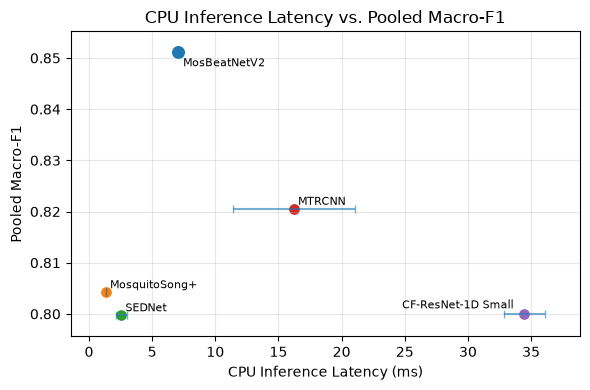

In [30]:
plot_df = df.dropna(subset=["Macro-F1"])

# Parameters vs Macro-F1
plt.figure(figsize=(6, 4))

for _, row in plot_df.iterrows():
    size = 70 if row["Model"] == "MosBeatNetV2" else 45

    plt.scatter(
        row["Params (M)"],
        row["Macro-F1"],
        s=size
    )

    offset = (4, -10) if row["Model"] == "MosBeatNetV2" else (3, 3)

    plt.annotate(
        row["Model"],
        (row["Params (M)"], row["Macro-F1"]),
        xytext=offset,
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel("Parameters (Million)")
plt.ylabel("Pooled Macro-F1")
plt.title("Model Parameters vs. Pooled Macro-F1")
plt.grid(alpha=0.3)
plt.margins(x=0.08, y=0.08)
plt.tight_layout()
plt.show()


# CPU latency vs Macro-F1
plt.figure(figsize=(6, 4))

for _, row in plot_df.iterrows():
    size = 70 if row["Model"] == "MosBeatNetV2" else 45

    plt.errorbar(
        row["CPU Latency (ms)"],
        row["Macro-F1"],
        xerr=row["CPU Std (ms)"],
        fmt="none",
        capsize=3,
        alpha=0.6
    )

    plt.scatter(
        row["CPU Latency (ms)"],
        row["Macro-F1"],
        s=size
    )

    if row["Model"] == "CF-ResNet-1D Small":
        offset = (-88, 4)
    elif row["Model"] == "MosBeatNetV2":
        offset = (4, -10)
    else:
        offset = (3, 3)

    plt.annotate(
        row["Model"],
        (row["CPU Latency (ms)"], row["Macro-F1"]),
        xytext=offset,
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel("CPU Inference Latency (ms)")
plt.ylabel("Pooled Macro-F1")
plt.title("CPU Inference Latency vs. Pooled Macro-F1")
plt.grid(alpha=0.3)
plt.margins(x=0.08, y=0.08)
plt.tight_layout()
plt.show()

In [ ]:
# Save CSV
df.to_csv("model_tradeoff.csv", index=False)
print("saved: model_tradeoff.csv")


saved: model_tradeoff.csv
